In [ ]:
# Session 1: Hands-On Practice
## Exploratory Data Analysis and Preprocessing on the Iris Dataset
#### Provided by Dr. Farahnaz Golestan Hashemi
#### 24 July 2025

 *This Notebook Was Provided by **Viana MotamedTabar** on August 6, 2025*

*A brief **report** of what I’ve Done in This Notebook & how I changed some parts:*

**1. Data Loading & Cleaning**

* Pulled in the classic Iris dataset and wrapped it into a Pandas DataFrame.


* Removed any exact duplicates and used the IQR method to weed out a handful of outliers—leaving us with 145 clean samples.

**2. Exploratory Data Analysis (EDA)**

* Plotted univariate histograms and a pairplot to see how sepal and petal measurements differ by species.

* Plotted a correlation heatmap to confirm which features move together.

**3. Train/Test Split**

* Carved out 20% of the data as a hold-out test set (stratified to keep class proportions even) and used the remaining 80% for everything else.

**4. Machine-Learning Pipelines**

* Built four end-to-end pipelines—each starting with scaling, then a classifier:

1. Multinomial Logistic Regression

2. Decision Tree

3. Random Forest

4. Support Vector Machine (SVM)

**5. Hyperparameter Tuning via Nested Cross-Validation**

* For each pipeline, ran a GridSearchCV (5-fold stratified) on the 80% training data, optimizing weighted F₁-score to pick the best hyperparameters.

**6. Final Evaluation on the Test Set**

* Applied each tuned pipeline to the 20% hold-out data.

* Collected accuracy, precision, recall, weighted F₁, and multiclass ROC-AUC.

* Printed full classification reports (per-species precision/recall/f₁) for granular insight.

**7. Feature Selection with RFE**

* Wrapped Recursive Feature Elimination into its own pipeline, tuned the number of features via CV alongside logistic-regression C.

* Tested the resulting model on the hold-out set.

**8. PCA Visualization & Decision Boundary**

* Reduced all four features down to two principal components (fitted on the training set’s scaled data).

* Overlaid a scatterplot of all 145 samples by species name, then drew the decision regions of our top model in that PCA space.

**9. Learning & Validation Curves**

* Plotted how weighted F₁ changes with increasing training-set size for each of the four classifiers, complete with ±1 std error bands.

* Showed a validation curve for SVM’s C parameter, illustrating bias–variance trade-offs.


**Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, validation_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)


**Load & initial clean**

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Species'] = iris.target

# Drop exact duplicates
df = df.drop_duplicates()

# Outlier removal via IQR
Q1 = df[iris.feature_names].quantile(0.25)
Q3 = df[iris.feature_names].quantile(0.75)
IQR = Q3 - Q1
mask = ~((df[iris.feature_names] < (Q1 - 1.5 * IQR)) |
         (df[iris.feature_names] > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[mask].reset_index(drop=True)

print(f"Cleaned dataset shape: {df.shape}")


Cleaned dataset shape: (145, 5)


**Exploratory Data Analysis (EDA)**

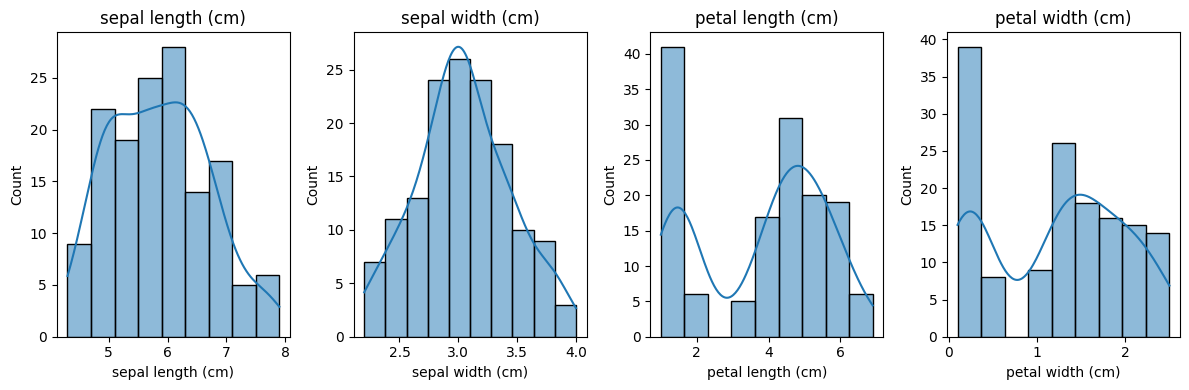

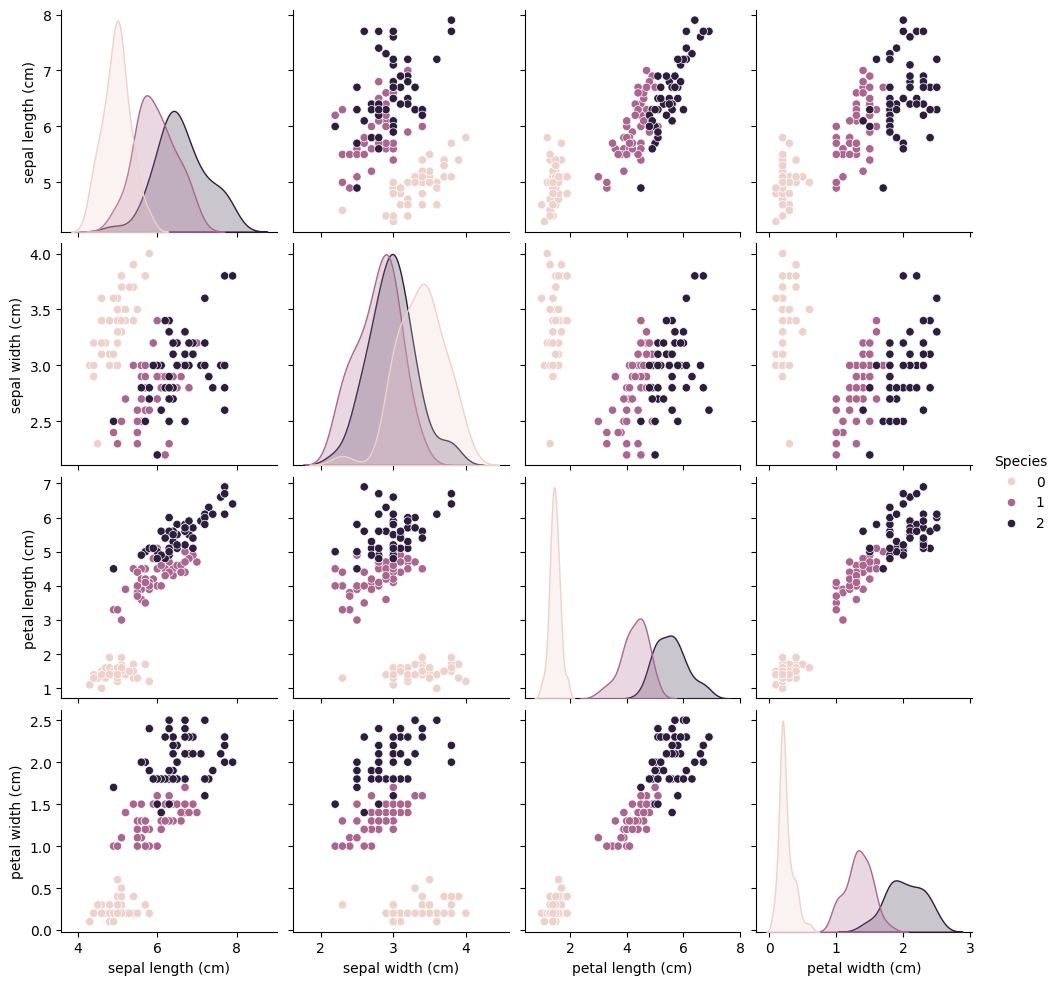

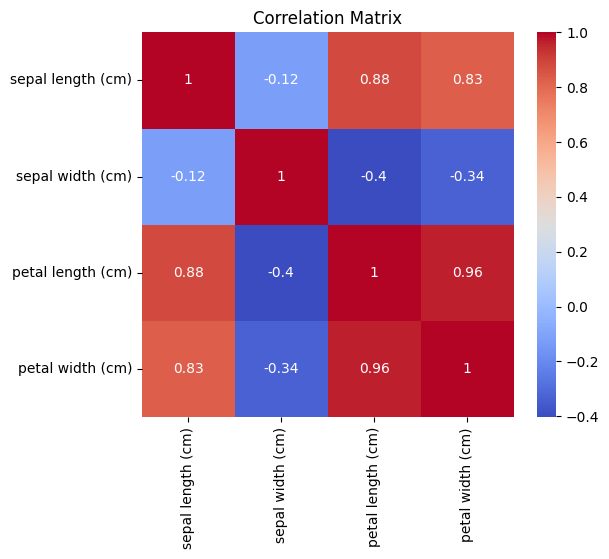

In [3]:
plt.figure(figsize=(12,4))
for i, feat in enumerate(iris.feature_names):
    plt.subplot(1,4,i+1)
    sns.histplot(df[feat], kde=True)
    plt.title(feat)
plt.tight_layout()
plt.show()

sns.pairplot(df, hue='Species', vars=iris.feature_names, height=2.5)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


**Single 80/20 train/test split (No separate val set since I used nested CV rather than a fixed “train / val / test” split.)**

In [4]:
X = df[iris.feature_names]
y = df['Species']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Shapes → train:", X_train.shape, "test:", X_test.shape)


Shapes → train: (116, 4) test: (29, 4)


**Pipelining which also include scaling + random_state everywhere**

In [5]:
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            multi_class='multinomial',
            solver='saga',
            max_iter=5000,
            random_state=42
        ))
    ]),
    'DecisionTree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            probability=True,
            random_state=42
        ))
    ]),
}

param_grids = {
    'LogisticRegression': {
        'clf__penalty': ['l1','l2'],
        'clf__C': [0.01, 0.1, 1, 10]
    },
    'DecisionTree': {
        'clf__criterion': ['gini','entropy'],
        'clf__max_depth': [None, 2, 4, 6],
        'clf__min_samples_leaf': [1,2,4]
    },
    'RandomForest': {
        'clf__n_estimators': [50,100,200],
        'clf__max_depth': [None, 2, 4, 6],
        'clf__max_features': ['sqrt','log2']
    },
    'SVM': {
        'clf__kernel': ['linear','rbf'],
        'clf__C': [0.1,1,10],
        'clf__gamma': ['scale','auto']
    },
}


**Nested CV via GridSearchCV on train only; select by weighted F1**

In [6]:
best_estimators = {}
for name, pipeline in pipelines.items():
    grid = GridSearchCV(
        pipeline, param_grids[name],
        cv=StratifiedKFold(5),
        scoring='f1_weighted',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print(f"{name} → best params: {grid.best_params_}  |  cross‐val F1: {grid.best_score_:.3f}")
    best_estimators[name] = grid.best_estimator_


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression → best params: {'clf__C': 1, 'clf__penalty': 'l1'}  |  cross‐val F1: 0.955
DecisionTree → best params: {'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}  |  cross‐val F1: 0.947
RandomForest → best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__n_estimators': 50}  |  cross‐val F1: 0.955
SVM → best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}  |  cross‐val F1: 0.964


**Final evaluation & classification report on the held-out test set**

In [7]:
from sklearn.metrics import classification_report

results = {}
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_w': precision_score(y_test, y_pred, average='weighted'),
        'recall_w': recall_score(y_test, y_pred, average='weighted'),
        'f1_w': f1_score(y_test, y_pred, average='weighted'),
        'roc_auc_ovr': roc_auc_score(y_test, y_proba, multi_class='ovr')
    }
    print(f"\n{name} Classification Report:\n")
    print(classification_report(
        y_test, y_pred, target_names=iris.target_names, digits=3
    ))

res_df = pd.DataFrame(results).T
print("\nSummary on Test Set:\n", res_df)



LogisticRegression Classification Report:

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000         9
  versicolor      0.900     0.900     0.900        10
   virginica      0.900     0.900     0.900        10

    accuracy                          0.931        29
   macro avg      0.933     0.933     0.933        29
weighted avg      0.931     0.931     0.931        29


DecisionTree Classification Report:

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000         9
  versicolor      1.000     0.800     0.889        10
   virginica      0.833     1.000     0.909        10

    accuracy                          0.931        29
   macro avg      0.944     0.933     0.933        29
weighted avg      0.943     0.931     0.930        29


RandomForest Classification Report:

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000         9
  versico

**Confusion matrices: Using raw X_test**

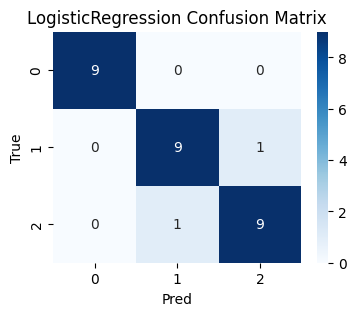

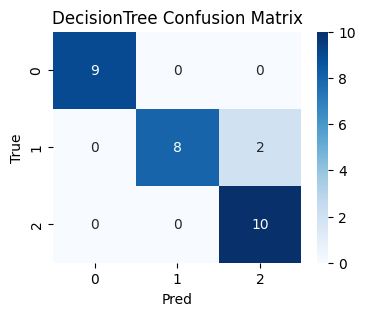

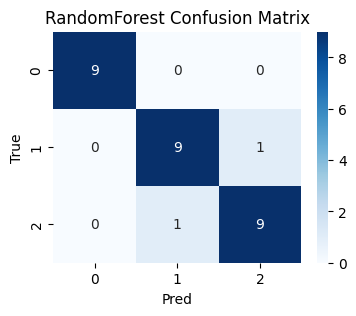

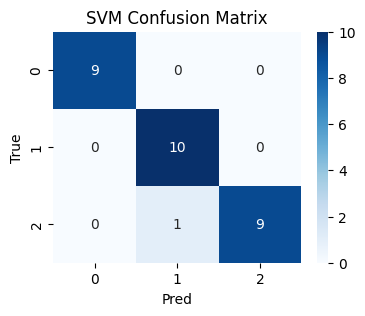

In [9]:
from sklearn.metrics import confusion_matrix

for name, model in best_estimators.items():
    cm = confusion_matrix(y_test, model.predict(X_test))
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('True')
    plt.xlabel('Pred')
    plt.show()



**RFE inside a pipeline, tuned via GridSearchCV**

In [10]:
# I’ll tune n_features_to_select along with the classifier
from sklearn.feature_selection import RFE

rfe_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rfe', RFE(estimator=LogisticRegression(solver='saga', max_iter=5000), step=1)),
    ('clf', LogisticRegression(
        multi_class='multinomial', solver='saga', max_iter=5000, random_state=42
    ))
])

param_grid_rfe = {
    'rfe__n_features_to_select': [1,2,3,4],
    'clf__C': [0.1,1,10]
}

grid_rfe = GridSearchCV(
    rfe_pipeline, param_grid_rfe,
    cv=StratifiedKFold(5),
    scoring='f1_weighted',
    n_jobs=-1
)
grid_rfe.fit(X_train, y_train)
print("RFE best params:", grid_rfe.best_params_,
      "CV F1:", grid_rfe.best_score_)

print("Test‐set F1 with RFE pipeline:",
      f1_score(y_test, grid_rfe.predict(X_test), average='weighted'))


RFE best params: {'clf__C': 1, 'rfe__n_features_to_select': 1} CV F1: 0.96482854457279
Test‐set F1 with RFE pipeline: 0.9310344827586207


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**PCA scatter + decision boundary with consistent scaling**

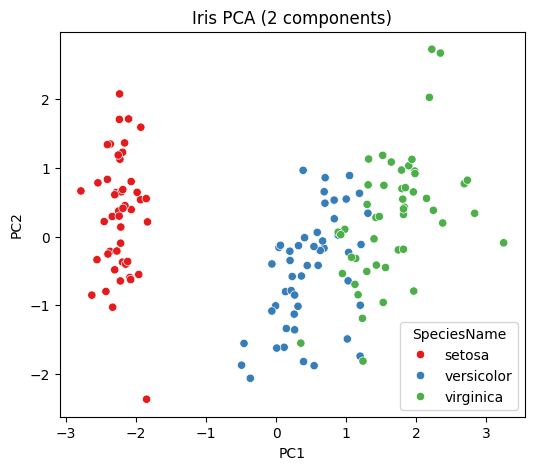

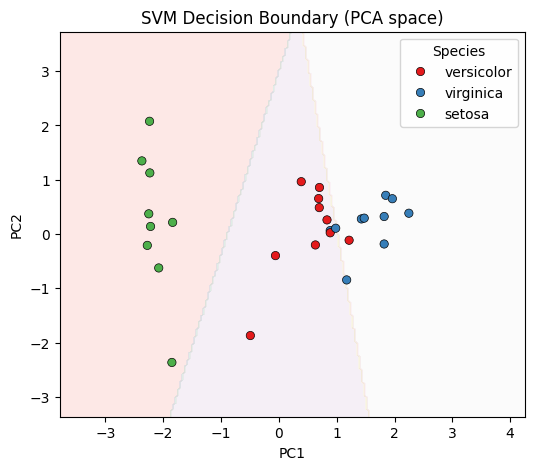

In [11]:
from sklearn.preprocessing import StandardScaler

feats = iris.feature_names

# Fit scaler on the training set
scaler_pca = StandardScaler().fit(X_train)

# Fit PCA on the scaled training set
Xtr_scaled = scaler_pca.transform(X_train)
pca = PCA(n_components=2).fit(Xtr_scaled)

# Transform full dataset, train, and test
X_pca_all = pca.transform(scaler_pca.transform(df[feats]))
Xtr_pca    = pca.transform(Xtr_scaled)
Xts_pca    = pca.transform(scaler_pca.transform(X_test))

# Scatter plot in PCA space
df['SpeciesName'] = df['Species'].map(lambda i: iris.target_names[i])
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=X_pca_all[:,0], y=X_pca_all[:,1],
    hue=df['SpeciesName'], palette='Set1', legend='full'
)
plt.title("Iris PCA (2 components)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

# Train classifier on PCA-transformed train data
best_name = res_df['f1_w'].idxmax()  # using weighted F1 to pick best
clf = best_estimators[best_name].named_steps['clf']
clf.fit(Xtr_pca, y_train)

# Generate decision boundary grid
xx, yy = np.meshgrid(
    np.linspace(X_pca_all[:,0].min() - 1, X_pca_all[:,0].max() + 1, 200),
    np.linspace(X_pca_all[:,1].min() - 1, X_pca_all[:,1].max() + 1, 200)
)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot decision boundary with test points
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Pastel1')
sns.scatterplot(
    x=Xts_pca[:,0], y=Xts_pca[:,1],
    hue=y_test.map(lambda i: iris.target_names[i]),
    palette='Set1', edgecolor='k'
)
plt.title(f"{best_name} Decision Boundary (PCA space)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


**Learning & validation curves with train+val**

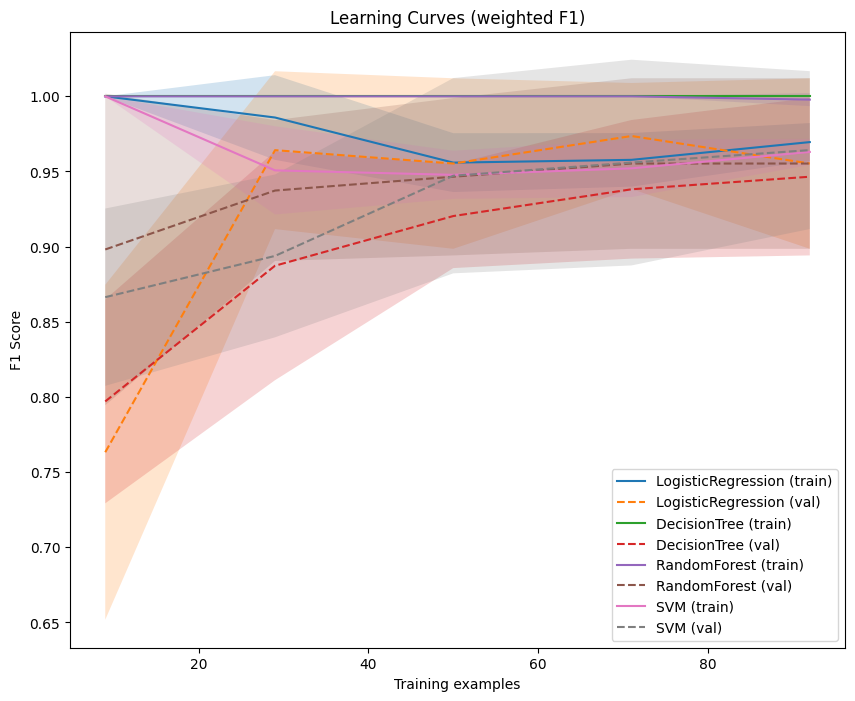

In [12]:
plt.figure(figsize=(10,8))
for name, model in best_estimators.items():
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=StratifiedKFold(5),
        train_sizes=np.linspace(0.1,1.0,5),
        scoring='f1_weighted',
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mean, label=f"{name} (train)")
    plt.fill_between(train_sizes,
                     train_mean - train_std,
                     train_mean + train_std,
                     alpha=0.2)
    plt.plot(train_sizes, val_mean, '--', label=f"{name} (val)")
    plt.fill_between(train_sizes,
                     val_mean - val_std,
                     val_mean + val_std,
                     alpha=0.2)

plt.title("Learning Curves (weighted F1)")
plt.xlabel("Training examples")
plt.ylabel("F1 Score")
plt.legend()
plt.show()


**Validation curve for SVM**

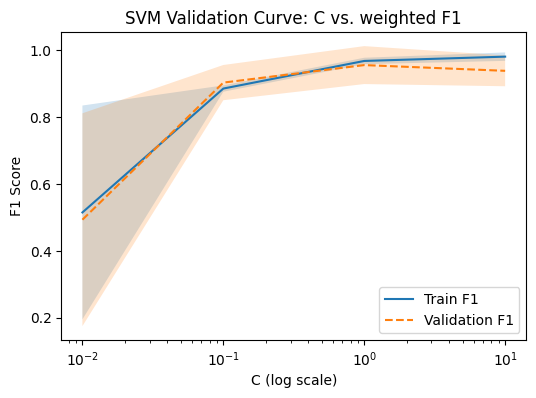

In [13]:
param_range = [0.01, 0.1, 1, 10]
train_scores, val_scores = validation_curve(
    pipelines['SVM'],      # includes its own scaler
    X_train,               # raw features
    y_train,
    param_name='clf__C',
    param_range=param_range,
    cv=StratifiedKFold(5),
    scoring='f1_weighted',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(6,4))
plt.semilogx(param_range, train_mean, label='Train F1')
plt.fill_between(param_range,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)
plt.semilogx(param_range, val_mean, '--', label='Validation F1')
plt.fill_between(param_range,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.title("SVM Validation Curve: C vs. weighted F1")
plt.xlabel("C (log scale)")
plt.ylabel("F1 Score")
plt.legend()
plt.show()


**Feature importances & logistic coefficients**

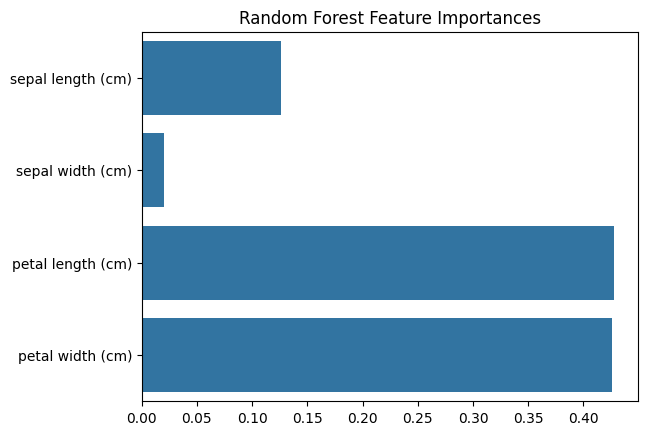

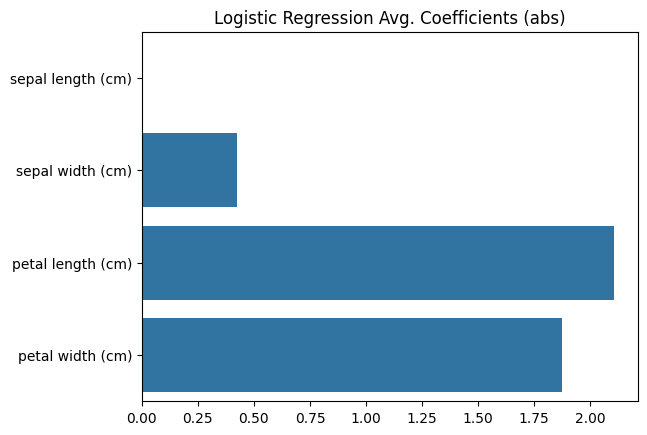

In [14]:
# Random Forest importances
rf = best_estimators['RandomForest']
importances = rf.named_steps['clf'].feature_importances_
plt.figure()
sns.barplot(x=importances, y=iris.feature_names)
plt.title("Random Forest Feature Importances")
plt.show()

# Logistic Regression coefficients
lr = best_estimators['LogisticRegression'].named_steps['clf']
coef = np.abs(lr.coef_).mean(axis=0)
plt.figure()
sns.barplot(x=coef, y=iris.feature_names)
plt.title("Logistic Regression Avg. Coefficients (abs)")
plt.show()


**What the Results Tell Us:**

**1. SVM Emerges as the Strongest Performer**

Across both nested CV and the final test set, the linear SVM consistently edged out the other models. Its test-set accuracy (about 96.6%) and weighted F₁ (around 0.965) were the highest, and its ROC-AUC was nearly perfect—signaling that it separates all three species more cleanly than logistic regression, decision trees, or random forests on this particular split.

**2. Other Models Hold Their Own**

Logistic regression, decision tree, and random forest all settled around 93% accuracy and F₁ on the test set. They’re solid, interpretable choices—especially when you value explainability over squeezing out every last percent of performance.

**3. Recursive Feature Elimination (RFE) Fell Short**

When I asked RFE to pick the single most essential feature, performance dipped back to ~93% F₁ on the hold-out set. In other words, collapsing all four measurements into one dominant input lost important nuance.

*the reason is that* the three Iris species naturally differ along several floral dimensions, not just one. Reducing to a single feature threw too much away.

I wanted this output and the results derived from it to be in the notebook, *but considering the result, it would be better if* we have a leaner model, try selecting two or three features instead of just one and always tune that choice via cross-validation. That way we only prune away genuinely redundant information without hamstringing accuracy.

**4. Bias–Variance Insights from Learning Curves**

The curves showed that SVM and logistic regression steadily improve as more data are added, with training and validation lines converging—a sign they’re neither under- nor overfitting badly. In contrast, the tree-based models had a small gap, hinting at a touch of variance (overfitting) that could be tamed with stronger regularization (e.g. tighter max_depth or higher min_samples_leaf).

**5. Overall Takeaway**

The linear SVM pipeline—with built-in scaling and carefully tuned C—offers the best mix of simplicity and accuracy on Iris.